## Colour Maps for Displaying Temperatures Using Clock face

The room temperature will be displayed on the clock face by changing the colour of certain LEDs based on a colour map specified by the user.
The room temperature will be split into three domains, each domain will have a distinct colour associated with it. In regions between two domains the colour will transition between the domain colours. There will be three types of transition supported:
1. Switching between domain colours (no transition region)
2. Linear transition, the colour will be a mix of the colours for each domain created by mixing the two domain colour based on the proportion of the transition between domains. (I.e. if the room temperature is halfway between the domains, the colour displayed will be a 50/50 mix of the domain colours.)
3. Non-linear transition, the colour will be a mix of the colours for each domain. The ratio of mixture will be a non-linear function (sigmoidal function) of the fraction of transition used above (option 2).


### Representing Temperature as Colour

Colours will be represented as RGB values $\overline{c}=\begin{pmatrix}r&g&b\end{pmatrix}$.

The temperature will be divided into three zones:
* Too cold ($t \leq T_L$)
* Just right ($T_L<t<T_H$)
* Too hot ($t \geq T_H$)

Each zone will be represented by it's own colour.

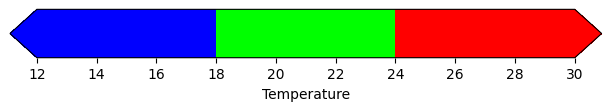

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

fig, ax = plt.subplots(figsize=(6, 1), layout='constrained')

too_cold = (0.0, 0.0, 1.0) # (r, g, b)
just_right = (0.0, 1.0, 0.0)
too_hot = (1.0, 0.0, 0.0)

cmap = (mpl.colors.ListedColormap([too_cold, just_right, too_hot]).with_extremes(under=too_cold, over=too_hot))
norm = mpl.colors.Normalize(vmin=12, vmax=30)

fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
             cax=ax, orientation='horizontal', label='Temperature', extend='both')

### Mixing Colour for Transition Between Zones

When mixing two colours the $\oplus$ operator will be used. For example $\overline{c_1} \oplus \overline{c_2}$ will denote the mixing of colours $\overline{c_1}$ and $\overline{c_2}$. It is expected that the mixing operator maybe implemented as a simple addition, i.e. $\overline{c_1} \oplus \overline{c_2} = \begin{pmatrix}r_1+r_2&g_1+g_2&b_1+b_2\end{pmatrix}$. However, for best aesthetics a more complex operation maybe required.

During the transition between two zones the temperature will be represented by a colour which is a mixture of the colours representative of the zones. The coulours will be mixed in a proportion ($f:(1-f)$) where $f \in [0,1]$ relates to how closed the current temperature is to one zone or the other. Thus the current temperature's representative colour will be $\overline{c} = f\overline{c_1} \oplus (1-f)\overline{c_2}$

The mixing factor $f$ will be a function of the current temperature $t$ given the limits of the transition zone $T_L$ and $T_H$, $f = F(t|T_L,T_H)$.

The simplest function will be a linear transition:

$$
f_l = \frac{t-T_L}{T_H-T_L}
$$

Alternatively a non-linear transition can be made by modifying the linear transition with a non-linear function (e.g. *sigmoid* function $S$) with domain and range in the interval:

 $$
 S\colon \mathbb{D} \in [0,1] \mapsto \mathbb{R} \in [0,1]
 $$

A sigmoid function may have a parameter, for example to adjust the "steepness" of the curve $s$.

$$
f_{nl} = S(f_l|s)
$$

where $f_l$ is defined above.

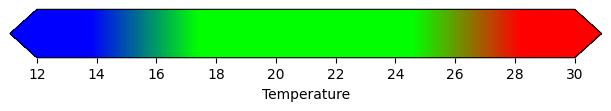

In [2]:
fig2, ax2 = plt.subplots(figsize=(6, 1), layout='constrained')

too_cold = (0.0, 0.0, 1.0) # (r, g, b)
just_right = (0.0, 1.0, 0.0)
too_hot = (1.0, 0.0, 0.0)

colours = [too_cold, too_cold, just_right, just_right, too_hot, too_hot]
nodes = [0.0, 0.1, 0.3, 0.7, 0.9, 1.0]
cmap2 = LinearSegmentedColormap.from_list('transition', list(zip(nodes, colours)))
norm = mpl.colors.Normalize(vmin=12, vmax=30)

fig2.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap2), cax=ax2, orientation='horizontal', label='Temperature', extend='both')